In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

project_path = '/content/drive/MyDrive/cnn_project'
os.makedirs(project_path, exist_ok=True)

In [3]:
import tensorflow as tf

In [4]:
import tensorflow.keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Flatten, Rescaling, GlobalAveragePooling2D, BatchNormalization, Resizing
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB0

In [6]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 550s 3us/step


In [7]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [10]:
# Convert labels to one-hot vectors
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [8]:
# Import the model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
base_model.layers

[<InputLayer name=input_layer, built=True>,
 <Rescaling name=rescaling, built=True>,
 <Normalization name=normalization, built=True>,
 <Rescaling name=rescaling_1, built=True>,
 <ZeroPadding2D name=stem_conv_pad, built=True>,
 <Conv2D name=stem_conv, built=True>,
 <BatchNormalization name=stem_bn, built=True>,
 <Activation name=stem_activation, built=True>,
 <DepthwiseConv2D name=block1a_dwconv, built=True>,
 <BatchNormalization name=block1a_bn, built=True>,
 <Activation name=block1a_activation, built=True>,
 <GlobalAveragePooling2D name=block1a_se_squeeze, built=True>,
 <Reshape name=block1a_se_reshape, built=True>,
 <Conv2D name=block1a_se_reduce, built=True>,
 <Conv2D name=block1a_se_expand, built=True>,
 <Multiply name=block1a_se_excite, built=True>,
 <Conv2D name=block1a_project_conv, built=True>,
 <BatchNormalization name=block1a_project_bn, built=True>,
 <Conv2D name=block2a_expand_conv, built=True>,
 <BatchNormalization name=block2a_expand_bn, built=True>,
 <Activation name=blo

In [37]:
# Freeze base model
base_model.trainable = False

In [47]:
# Add custom classifier on top

model_effnet_b0 = Sequential([
    base_model,
    GlobalAveragePooling2D(), # Pool spatial features into a vector
    Dense(128, activation='relu'), # Fully connected layer to learn new patterns
    Dropout(0.3),
    Dense(10, activation='softmax') # Output layer with 10 classes
])

In [39]:
model_effnet_b0.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [40]:
# Compile the model

model_effnet_b0.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )

In [41]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn2/best_model_effnet_b0.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=2
)


history_effnet_b0 = model_effnet_b0.fit(X_train, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping, reduce_LR])

Epoch 1/50
1245/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7116 - loss: 0.8715
Epoch 1: val_loss improved from None to 0.98195, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.7387 - loss: 0.7746 - val_accuracy: 0.6768 - val_loss: 0.9819 - learning_rate: 0.0010
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7603 - loss: 0.6755
Epoch 2: val_loss did not improve from 0.98195
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7612 - loss: 0.6752 - val_accuracy: 0.6743 - val_loss: 1.0009 - learning_rate: 0.0010
Epoch 3/50
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7683 - loss: 0.6444
Epoch 3: val_loss did not improve from 0.98195
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7673 - loss: 0.6515 - val_accuracy: 

In [42]:
# Fitting results (best epoch was 1, which is index 0)
train_acc = history_effnet_b0.history['accuracy'][0]
train_loss = history_effnet_b0.history['loss'][0]
val_acc = history_effnet_b0.history['val_accuracy'][0]
val_loss = history_effnet_b0.history['val_loss'][0]

print("Epoch 39")
print(f"Train accuracy:{train_acc:.4f}")
print(f"Train loss:{train_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

Epoch 39
Train accuracy:0.7387
Train loss:0.7746
Validation accuracy: 0.6768
Validation loss: 0.9819


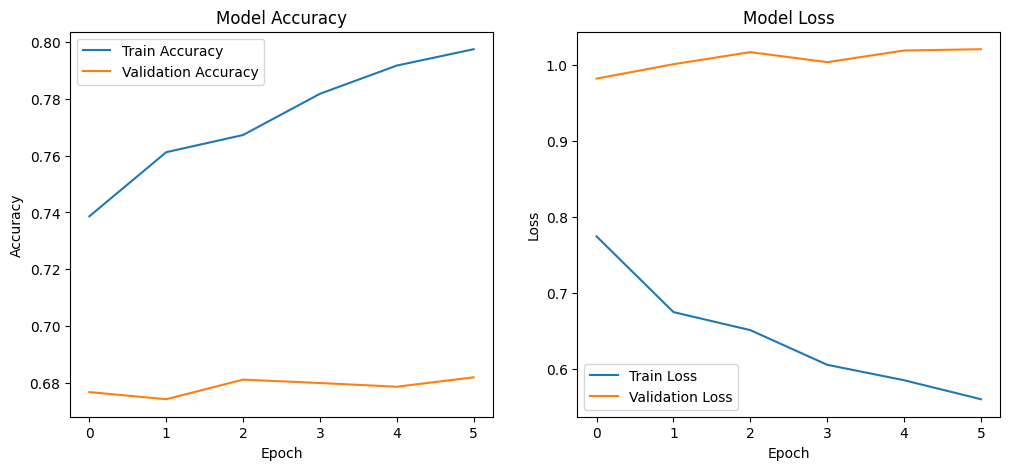

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_effnet_b0.history['accuracy'], label='Train Accuracy')
plt.plot(history_effnet_b0.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_effnet_b0.history['loss'], label='Train Loss')
plt.plot(history_effnet_b0.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Both training and validation accuracy are low and training and validation loss are high, meaning the model needs improvement.

In [56]:
# Change input shape to 224, 224, 3
# Import the model
base_model_2 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [57]:
# Freeze base_model_2
base_model_2.trainable = False

In [94]:
# Add custom classifier on top

model_effnet_b0_2 = Sequential([
    Resizing(224, 224),
    base_model_2,
    GlobalAveragePooling2D(), # Pool spatial features into a vector
    Dense(128, activation='relu'), # Fully connected layer to learn new patterns
    Dropout(0.3),
    Dense(10, activation='softmax') # Output layer with 10 classes
])

In [59]:
model_effnet_b0_2.summary()

# Compile the model
model_effnet_b0_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [60]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn2/best_model_effnet_b0_2.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=2
)


history_effnet_b0_2 = model_effnet_b0_2.fit(X_train, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping, reduce_LR])

Epoch 1/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7960 - loss: 0.6124
Epoch 1: val_loss improved from None to 0.29340, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 52ms/step - accuracy: 0.8449 - loss: 0.4544 - val_accuracy: 0.8969 - val_loss: 0.2934 - learning_rate: 0.0010
Epoch 2/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8889 - loss: 0.3256
Epoch 2: val_loss improved from 0.29340 to 0.27306, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.8884 - loss: 0.3282 - val_accuracy: 0.9064 - val_loss: 0.2731 - learning_rate: 0.0010
Epoch

In [62]:
# Fitting results (best epoch was 10, which is index 9)
train_acc_2 = history_effnet_b0_2.history['accuracy'][9]
train_loss_2 = history_effnet_b0_2.history['loss'][9]
val_acc_2 = history_effnet_b0_2.history['val_accuracy'][9]
val_loss_2 = history_effnet_b0_2.history['val_loss'][9]

print("Epoch 10")
print(f"Train accuracy:{train_acc_2:.4f}")
print(f"Train loss:{train_loss_2:.4f}")
print(f"Validation accuracy: {val_acc_2:.4f}")
print(f"Validation loss: {val_loss_2:.4f}")

Epoch 10
Train accuracy:0.9449
Train loss:0.1532
Validation accuracy: 0.9193
Validation loss: 0.2470


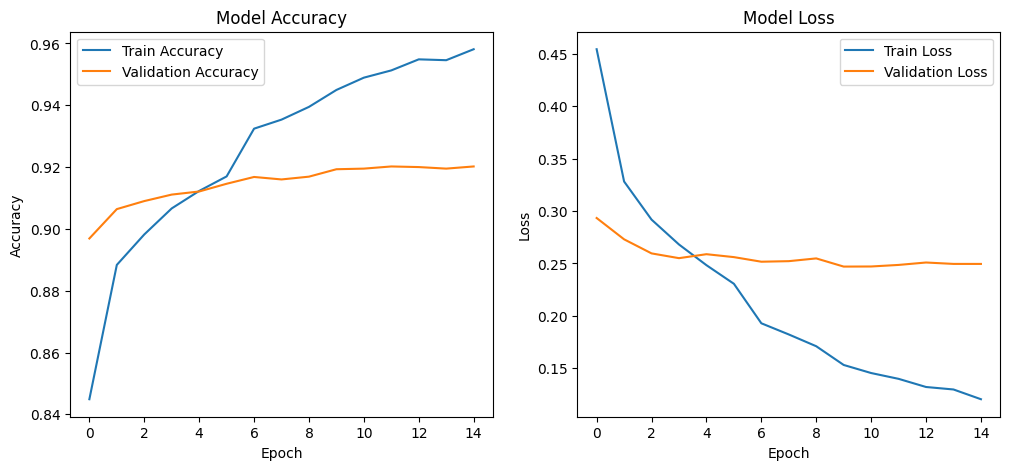

In [63]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_effnet_b0_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_effnet_b0_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_effnet_b0_2.history['loss'], label='Train Loss')
plt.plot(history_effnet_b0_2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The model achieved a good performance in terms of accuracy, but need improvement on the loss values.

Next, unfreezing the last 20 layers will be performed.

In [90]:
len(base_model_2.layers)

238

In [91]:
# Unfreeze last 20 layers of base_model_2 for fine-tuning
base_model_2.trainable = True

# Freeze all layers except the last 20
fine_tune_at = len(base_model_2.layers) - 20
for layer in base_model_2.layers[:fine_tune_at]:
    layer.trainable = False

fine_tune_at

218

In [92]:
# Compile the model
model_effnet_b0_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )

In [93]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn2/best_model_effnet_b0_3.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=3,
           min_lr=1e-7
)


history_effnet_b0_3 = model_effnet_b0_2.fit(X_train, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping, reduce_LR])

Epoch 1/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9620 - loss: 0.1370
Epoch 1: val_loss improved from None to 0.22853, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_3.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 99s 58ms/step - accuracy: 0.9614 - loss: 0.1292 - val_accuracy: 0.9412 - val_loss: 0.2285 - learning_rate: 0.0010
Epoch 2/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9727 - loss: 0.0892
Epoch 2: val_loss improved from 0.22853 to 0.20985, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_3.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 48ms/step - accuracy: 0.9697 - loss: 0.0989 - val_accuracy: 0.9442 - val_loss: 0.2099 - learning_rate: 0.0010
Epoch

In [95]:
# Fitting results (best epoch was 2, which is index 1)
train_acc_3 = history_effnet_b0_3.history['accuracy'][1]
train_loss_3 = history_effnet_b0_3.history['loss'][1]
val_acc_3 = history_effnet_b0_3.history['val_accuracy'][1]
val_loss_3 = history_effnet_b0_3.history['val_loss'][1]

print("Epoch 2")
print(f"Train accuracy:{train_acc_3:.4f}")
print(f"Train loss:{train_loss_3:.4f}")
print(f"Validation accuracy: {val_acc_3:.4f}")
print(f"Validation loss: {val_loss_3:.4f}")

Epoch 2
Train accuracy:0.9697
Train loss:0.0989
Validation accuracy: 0.9442
Validation loss: 0.2099


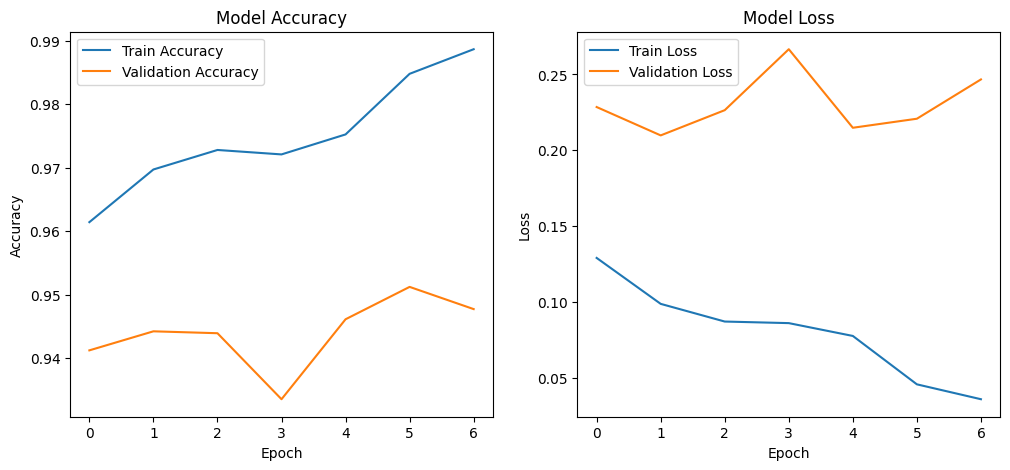

In [96]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_effnet_b0_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_effnet_b0_3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_effnet_b0_3.history['loss'], label='Train Loss')
plt.plot(history_effnet_b0_3.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The unfreezing of the last 20 layers improved the model's performance.

Unfreezing more layers will be tested.

In [97]:
# Unfreeze last 40 layers of base_model_2 for fine-tuning
base_model_2.trainable = True

# Freeze all layers except the last 40
fine_tune_at = len(base_model_2.layers) - 40
for layer in base_model_2.layers[:fine_tune_at]:
    layer.trainable = False

fine_tune_at

198

In [98]:
model_effnet_b0_2.summary()

# Compile the model
model_effnet_b0_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (32, 7, 7, 1280)       │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 1,350,960 (5.15 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

In [99]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn2/best_model_effnet_b0_4.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=3,
           min_lr=1e-7
)


history_effnet_b0_4 = model_effnet_b0_2.fit(X_train, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping, reduce_LR])

Epoch 1/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9525 - loss: 0.1794
Epoch 1: val_loss improved from None to 0.24852, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_4.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 100s 58ms/step - accuracy: 0.9653 - loss: 0.1176 - val_accuracy: 0.9379 - val_loss: 0.2485 - learning_rate: 0.0010
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9733 - loss: 0.0823
Epoch 2: val_loss improved from 0.24852 to 0.24049, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_4.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.9725 - loss: 0.0852 - val_accuracy: 0.9389 - val_loss: 0.2405 - learning_rate: 0.0010
Epoc

In [105]:
# Fitting results (best epoch was 3, which is index 2)
train_acc_4 = history_effnet_b0_4.history['accuracy'][2]
train_loss_4 = history_effnet_b0_4.history['loss'][2]
val_acc_4 = history_effnet_b0_4.history['val_accuracy'][2]
val_loss_4 = history_effnet_b0_4.history['val_loss'][2]

print("Epoch 3")
print(f"Train accuracy:{train_acc_4:.4f}")
print(f"Train loss:{train_loss_4:.4f}")
print(f"Validation accuracy: {val_acc_4:.4f}")
print(f"Validation loss: {val_loss_4:.4f}")

Epoch 3
Train accuracy:0.9761
Train loss:0.0720
Validation accuracy: 0.9447
Validation loss: 0.2118


Unfreezing more layers slightly improve the train accuracy and decreased the train loss.

In [102]:
# Add convolutional layer

model_effnet_b0_3 = Sequential([
    Resizing(224, 224),
    base_model_2,
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling2D(), # Pool spatial features into a vector
    Dense(128, activation='relu'), # Fully connected layer to learn new patterns
    Dropout(0.3),
    Dense(10, activation='softmax') # Output layer with 10 classes
])

In [103]:
model_effnet_b0_3.summary()

# Compile the model
model_effnet_b0_3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_4 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (32, 7, 7, 1280)       │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 1,350,960 (5.15 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

In [104]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn2/best_model_effnet_b0_5.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=3,
           min_lr=1e-7
)


history_effnet_b0_5 = model_effnet_b0_3.fit(X_train, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping, reduce_LR])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9612 - loss: 0.1304
Epoch 1: val_loss improved from None to 0.22516, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_5.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_5.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 119s 71ms/step - accuracy: 0.9672 - loss: 0.1052 - val_accuracy: 0.9436 - val_loss: 0.2252 - learning_rate: 0.0010
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9789 - loss: 0.0693
Epoch 2: val_loss improved from 0.22516 to 0.22027, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_5.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn2/best_model_effnet_b0_5.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.9762 - loss: 0.0763 - val_accuracy: 0.9419 - val_loss: 0.2203 - learning_rate: 0.0010
Epoc

In [114]:
# Fitting results (best epoch was 8, which is index 7)
train_acc_5 = history_effnet_b0_5.history['accuracy'][7]
train_loss_5 = history_effnet_b0_5.history['loss'][7]
val_acc_5 = history_effnet_b0_5.history['val_accuracy'][7]
val_loss_5 = history_effnet_b0_5.history['val_loss'][7]

print("Epoch 8")
print(f"Train accuracy:{train_acc_5:.4f}")
print(f"Train loss:{train_loss_5:.4f}")
print(f"Validation accuracy: {val_acc_5:.4f}")
print(f"Validation loss: {val_loss_5:.4f}")

Epoch 8
Train accuracy:0.9919
Train loss:0.0247
Validation accuracy: 0.9521
Validation loss: 0.2034


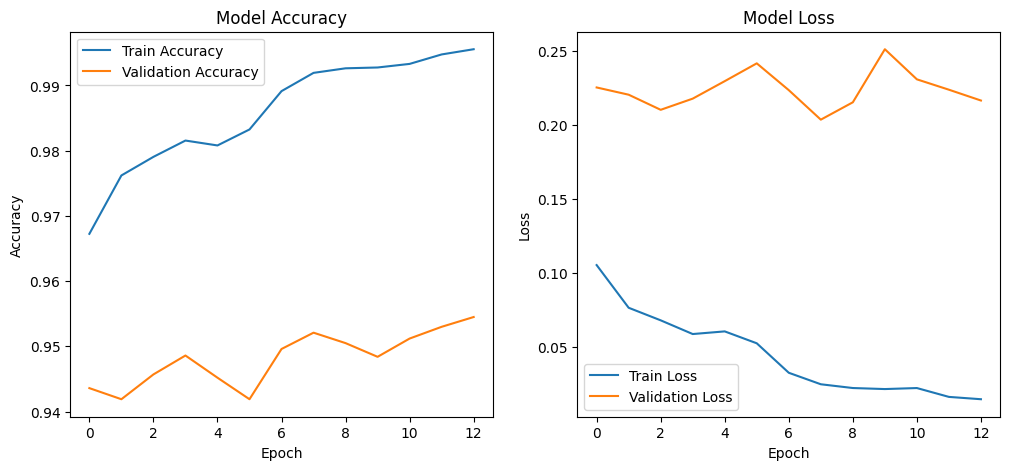

In [108]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_effnet_b0_5.history['accuracy'], label='Train Accuracy')
plt.plot(history_effnet_b0_5.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_effnet_b0_5.history['loss'], label='Train Loss')
plt.plot(history_effnet_b0_5.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

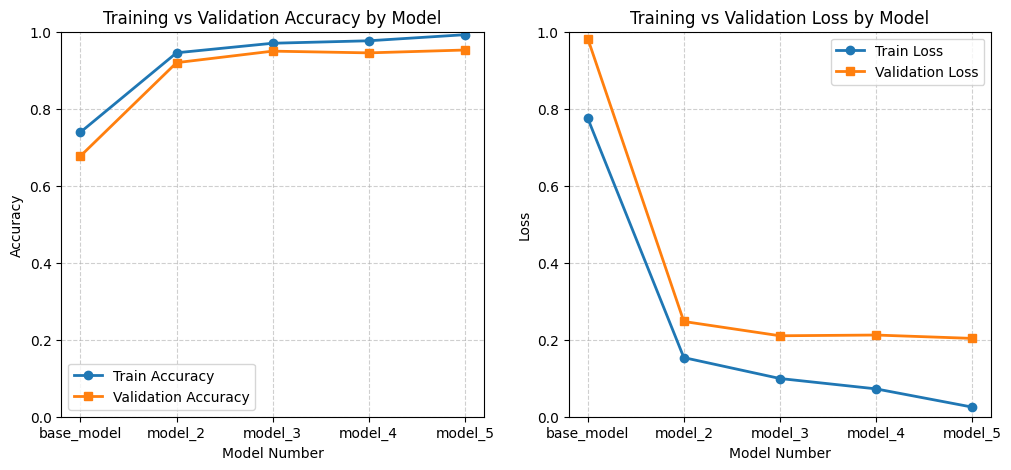

In [7]:
# Plot different accuracy and loss values for each model

# Accuracies
train_accuracies = [0.7387, 0.9449, 0.9697, 0.9761, 0.9919]
val_accuracies = [0.6768, 0.9193, 0.9492, 0.9447, 0.9521]

# Losses
train_losses = [0.7746, 0.1532, 0.0989, 0.0720, 0.0247]
val_losses = [0.9819, 0.2470, 0.2099, 0.2118, 0.2031]


models = ['base_model', 'model_2', 'model_3', 'model_4', 'model_5']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(models, train_accuracies, marker='o', linewidth=2, label='Train Accuracy')
plt.plot(models, val_accuracies, marker='s', linewidth=2, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy by Model')
plt.xlabel('Model Number')
plt.ylabel('Accuracy')
plt.xticks(models)
plt.ylim(0, 1)   # because accuracy goes from 0 to 1
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(models, train_losses, marker='o', linewidth=2, label='Train Loss')
plt.plot(models, val_losses, marker='s', linewidth=2, label='Validation Loss')

plt.title('Training vs Validation Loss by Model')
plt.xlabel('Model Number')
plt.ylabel('Loss')
plt.xticks(models)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [110]:
# Evaluate method
test_loss, test_acc = model_effnet_b0_3.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.9490 - loss: 0.2285
Test Accuracy: 0.9490
Test Loss: 0.2285


In [111]:
# Predictions
y_pred_probs = model_effnet_b0_3.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step


In [112]:
# Classification report
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.97      0.96      0.96      1000
  automobile       0.97      0.97      0.97      1000
        bird       0.97      0.93      0.95      1000
         cat       0.90      0.88      0.89      1000
        deer       0.95      0.95      0.95      1000
         dog       0.89      0.93      0.91      1000
        frog       0.97      0.97      0.97      1000
       horse       0.96      0.97      0.97      1000
        ship       0.97      0.97      0.97      1000
       truck       0.96      0.97      0.96      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



**Class-by-Class Insights**

| Class         | Precision | Recall | F1-score | Support | Interpretation |
|---------------|-----------|--------|----------|---------|----------------|
| **airplane** | 0.97      | 0.96   | 0.96     | 1000    |  Excelent performance|
| **automobile**     | 0.97      | 0.97   | 0.97     | 1000    | Excellent performance|
| **bird**    | 0.97      | 0.93   | 0.95     | 1000    | Great performance |
| **cat**       | 0.90      | 0.88   | 0.89     | 1000    | Worst performing class. Some cat are being identified as dogs. |
| **deer**        | 0.95      | 0.95   | 0.95     | 1000    | Excelent performance |
| **dog**      | 0.89      | 0.93   | 0.91     | 1000    | Good performance. Some cats are being identified as dogs. |
| **frog**       | 0.97      | 0.97   | 0.97     | 1000    | Excelent performance |
| **horse**     | 0.96      | 0.97   | 0.97     | 1000    | Excelent performance |
| **ship**         | 0.97      | 0.97   | 0.97     | 1000    | Excelent performance |
| **truck**  | 0.96      | 0.97   | 0.96     | 1000    | Excelent performance |

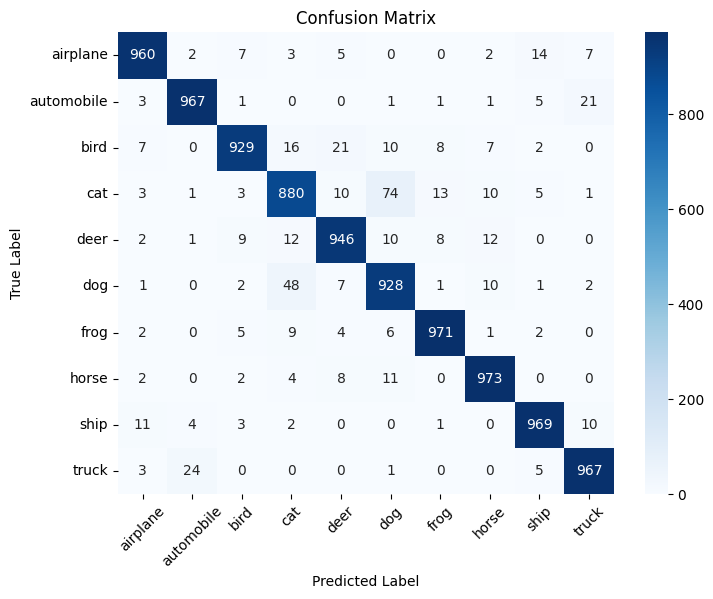

In [113]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [115]:
model_effnet_b0_3.save(f'{project_path}/models/efficientnetb0_cifar10.keras')